In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.fc1 = nn.Linear(128*4*4, 128)
        self.fc2 = nn.Linear(128, 10)
    def forward(self, x):
        x = F.relu(self.conv1(x)); x = self.pool(x)
        x = F.relu(self.conv2(x)); x = self.pool(x)
        x = F.relu(self.conv3(x)); x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [4]:
def train():
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

    model = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    EPOCHS = 8
    train_acc = []
    val_acc = []
    for epoch in range(EPOCHS):
        model.train()
        running = 0
        total = 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            opt.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            opt.step()
            _, preds = outputs.max(1)
            running += (preds == labels).sum().item()
            total += labels.size(0)
        train_acc.append(running/total)
        model.eval()
        correct = 0; total = 0
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = outputs.max(1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_acc.append(correct/total)
        print(f"Epoch {epoch+1}/{EPOCHS} train_acc={train_acc[-1]:.4f} val_acc={val_acc[-1]:.4f}")
    
    plt.figure()
    plt.plot(train_acc, label='train_acc')
    plt.plot(val_acc, label='val_acc')
    plt.legend()
    plt.title("PyTorch CNN accuracy")
    plt.show()
    torch.save(model.state_dict(), "pytorch_cnn.pth")

Epoch 1/8 train_acc=0.4507 val_acc=0.5596
Epoch 2/8 train_acc=0.6092 val_acc=0.6509
Epoch 3/8 train_acc=0.6797 val_acc=0.6901
Epoch 4/8 train_acc=0.7227 val_acc=0.7025
Epoch 5/8 train_acc=0.7546 val_acc=0.7196
Epoch 6/8 train_acc=0.7808 val_acc=0.7336
Epoch 7/8 train_acc=0.8028 val_acc=0.7471
Epoch 8/8 train_acc=0.8283 val_acc=0.7382


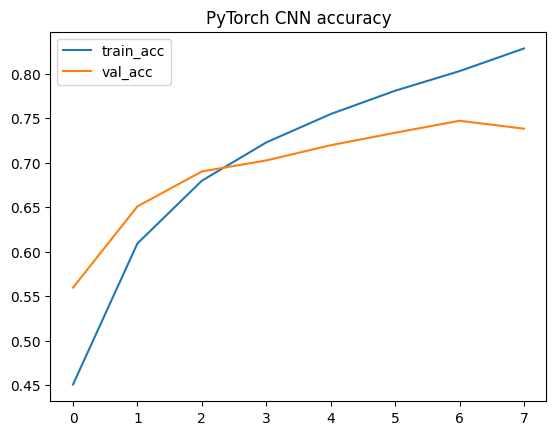

In [5]:
train()